# Fase 17c: Verificación de robustez (overfitting/underfitting) y uso práctico

## Objetivo

Responder con rigor:
1. **¿El clasificador de dirección sufre overfitting o underfitting?**
   (gap train/val/test, learning curve, estabilidad entre semillas,
   submuestreo).
2. **¿Generaliza fuera del test fijo 2023-25?** (walk-forward con
   reentrenamiento anual 2019-2025).
3. **¿Es útil en la práctica para decidir cuándo invertir?**
   (backtest por régimen de mercado, estrategia de reducción de exposición).

## Diagnóstico previo (fase 17b)

El RF profundo (max_depth=None) tenía train AUC=1.0 vs test 0.57
-> **overfitting severo**. La regularización (depth=4, leaf=20) reduce
el gap a 0.126 manteniendo test AUC=0.569.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import path_from_root, set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga de datos y preparación.

Reutilizamos features, split, feature_list y targets de dirección.

In [2]:
import json

import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup, temporal_split
from src.models.classifier import make_direction_targets

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)
fdir = make_direction_targets(feats, [1])

train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
train_val = train_val.merge(fdir[["date", "dir_1"]], on="date", how="left")
te = parts["test"].merge(fdir[["date", "dir_1"]], on="date", how="left")
X_tv = train_val[sel_cols].to_numpy(np.float64)
y_tv = train_val["dir_1"].to_numpy()
X_te = te[sel_cols].to_numpy(np.float64)
y_te = te["dir_1"].to_numpy()
print(f"train+val: {len(X_tv)} | test: {len(X_te)} | features: {len(sel_cols)}")

train+val: 5739 | test: 684 | features: 110


1. Gap train/val/test: ¿overfitting?

Comparamos el AUC en train, val y test para tres niveles de regularización.
Un modelo que memoriza tiene train AUC ~1.0 y test ~0.55 (gap enorme).

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from src.models.pipeline import fit_preprocessor

pp = fit_preprocessor(X_tv)
va = parts["val"].merge(fdir[["date", "dir_1"]], on="date", how="left")
X_va = va[sel_cols].to_numpy(np.float64)
y_va = va["dir_1"].to_numpy()

print("=== Gap train/val/test por nivel de regularización ===")
configs = {
    "RF profundo (depth=None, leaf=2)": dict(max_depth=None, min_samples_leaf=2),
    "RF actual (depth=8, leaf=10)": dict(max_depth=8, min_samples_leaf=10),
    "RF regularizado (depth=4, leaf=20)": dict(max_depth=4, min_samples_leaf=20),
}
for name, params in configs.items():
    m = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, **params)
    m.fit(pp.transform(X_tv), y_tv)
    tr_auc = roc_auc_score(y_tv, m.predict_proba(pp.transform(X_tv))[:, 1])
    va_auc = roc_auc_score(y_va, m.predict_proba(pp.transform(X_va))[:, 1])
    te_auc = roc_auc_score(y_te, m.predict_proba(pp.transform(X_te))[:, 1])
    print(f"{name:32s}: train={tr_auc:.4f} val={va_auc:.4f} test={te_auc:.4f} "
          f"gap={tr_auc - te_auc:.4f}")

=== Gap train/val/test por nivel de regularización ===


RF profundo (depth=None, leaf=2): train=1.0000 val=1.0000 test=0.5713 gap=0.4287


RF actual (depth=8, leaf=10)    : train=0.9112 val=0.9653 test=0.5590 gap=0.3522


RF regularizado (depth=4, leaf=20): train=0.6947 val=0.7184 test=0.5692 gap=0.1255


2. Learning curve y estabilidad entre semillas.

- Learning curve: si el gap train-val NO se cierra al crecer train, hay
  overfitting estructural (el modelo memoriza el ruido).
- Semillas: el test AUC debe ser estable (no depender de una semilla).

In [4]:
from src.data.split import get_temporal_splitter

tscv = get_temporal_splitter(cfg)
print("=== Learning curve (RF regularizado depth=4, leaf=20) ===")
for i, (tr_idx, va_idx) in enumerate(tscv.split(X_tv)):
    pp2 = fit_preprocessor(X_tv[tr_idx])
    m = RandomForestClassifier(n_estimators=300, max_depth=4,
                               min_samples_leaf=20, random_state=42, n_jobs=-1)
    m.fit(pp2.transform(X_tv[tr_idx]), y_tv[tr_idx])
    tr_auc = roc_auc_score(y_tv[tr_idx],
                           m.predict_proba(pp2.transform(X_tv[tr_idx]))[:, 1])
    va_auc = roc_auc_score(y_tv[va_idx],
                           m.predict_proba(pp2.transform(X_tv[va_idx]))[:, 1])
    print(f"fold {i} (train={len(tr_idx):5d}): train AUC={tr_auc:.4f} | "
          f"val AUC={va_auc:.4f} | gap={tr_auc - va_auc:.4f}")

print("\n=== Estabilidad entre semillas (test AUC) ===")
aucs = []
for seed in [42, 7, 123, 999, 2024]:
    m = RandomForestClassifier(n_estimators=300, max_depth=4,
                               min_samples_leaf=20, random_state=seed, n_jobs=-1)
    m.fit(pp.transform(X_tv), y_tv)
    a = roc_auc_score(y_te, m.predict_proba(pp.transform(X_te))[:, 1])
    aucs.append(a)
    print(f"  seed {seed}: test AUC={a:.4f}")
print(f"  media={np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

=== Learning curve (RF regularizado depth=4, leaf=20) ===


fold 0 (train=  938): train AUC=0.8474 | val AUC=0.5532 | gap=0.2942


fold 1 (train= 1894): train AUC=0.7800 | val AUC=0.5485 | gap=0.2315


fold 2 (train= 2850): train AUC=0.7278 | val AUC=0.5174 | gap=0.2104


fold 3 (train= 3806): train AUC=0.7119 | val AUC=0.5201 | gap=0.1917


...

  seed 42: test AUC=0.5692


  seed 7: test AUC=0.5549


  seed 123: test AUC=0.5544


  seed 999: test AUC=0.5568


  seed 2024: test AUC=0.5496
  media=0.5570 ± 0.0066


3. WALK-FORWARD: generalización real fuera del test fijo.

Reentrenamos cada año con ventana móvil de 5 años y evaluamos el año
siguiente (2019-2025). Esto simula el uso real en producción y evita
que un solo periodo de test (2023-25, rally) condicione la conclusión.

In [5]:
feats_wf = drop_warmup(feats, warmup=260).merge(
    fdir[["date", "dir_1"]], on="date", how="left")
years = sorted(feats_wf["date"].dt.year.unique())
wf_rows = []
print("=== Walk-forward (entrenar 5 años, evaluar el siguiente) ===")
for train_end in range(2018, 2025):
    train = feats_wf[(feats_wf["date"].dt.year >= train_end - 4) &
                     (feats_wf["date"].dt.year <= train_end)]
    test = feats_wf[feats_wf["date"].dt.year == train_end + 1]
    if len(train) < 500 or len(test) < 100:
        continue
    X_tr = train[sel_cols].to_numpy(np.float64)
    y_tr = train["dir_1"].to_numpy()
    X_te2 = test[sel_cols].to_numpy(np.float64)
    y_te2 = test["dir_1"].to_numpy()
    pp3 = fit_preprocessor(X_tr)
    m = RandomForestClassifier(n_estimators=300, max_depth=4,
                               min_samples_leaf=20, random_state=42, n_jobs=-1)
    m.fit(pp3.transform(X_tr), y_tr)
    pt = m.predict_proba(pp3.transform(X_te2))[:, 1]
    auc = roc_auc_score(y_te2, pt)
    ret = test["target_1"].to_numpy() / test["gold_spot"].to_numpy() - 1
    mask = ~np.isnan(ret)
    ret = ret[mask]
    pt_m = pt[mask]
    pos = (pt_m >= 0.5).astype(int)
    r = pos * ret
    changes = np.abs(np.diff(pos, prepend=pos[0]))
    strat = np.cumprod(1 + r - 0.001 * changes)[-1] - 1
    bh = np.cumprod(1 + ret)[-1] - 1
    p_up = (ret[pos.astype(bool)] > 0).mean() if pos.sum() > 0 else float("nan")
    print(f"train {train_end-4}-{train_end} -> eval {train_end+1}: "
          f"AUC={auc:.4f} | estr={strat:7.1%} buyhold={bh:7.1%} "
          f"P(sube|pred)={p_up:.1%} (n={len(test)})")
    wf_rows.append({"year": train_end + 1, "auc": auc, "strat": strat, "bh": bh})

wf = pd.DataFrame(wf_rows)
print(f"\n=== Resumen walk-forward ===")
print(f"AUC medio: {wf['auc'].mean():.4f} ± {wf['auc'].std():.4f}")
print(f"AUC > 0.55 en {int((wf['auc'] > 0.55).sum())}/{len(wf)} años")
print(f"Estrategia gana a buy&hold en {int((wf['strat'] > wf['bh']).sum())}/{len(wf)} años")
print(f"Estrategia media: {wf['strat'].mean():.1%} | buy&hold medio: {wf['bh'].mean():.1%}")

=== Walk-forward (entrenar 5 años, evaluar el siguiente) ===


train 2014-2018 -> eval 2019: AUC=0.5502 | estr=   4.1% buyhold=  18.3% P(sube|pred)=59.0% (n=261)


train 2015-2019 -> eval 2020: AUC=0.5218 | estr=   2.6% buyhold=  25.1% P(sube|pred)=59.5% (n=262)


train 2016-2020 -> eval 2021: AUC=0.5014 | estr=  -8.3% buyhold=  -5.1% P(sube|pred)=50.4% (n=261)


train 2017-2021 -> eval 2022: AUC=0.4820 | estr=  -7.7% buyhold=   1.3% P(sube|pred)=51.3% (n=260)


train 2018-2022 -> eval 2023: AUC=0.5138 | estr=   4.5% buyhold=  13.2% P(sube|pred)=50.9% (n=260)


train 2019-2023 -> eval 2024: AUC=0.5449 | estr=  11.7% buyhold=  27.1% P(sube|pred)=60.2% (n=262)


train 2020-2024 -> eval 2025: AUC=0.6562 | estr=  31.6% buyhold=  27.1% P(sube|pred)=58.0% (n=162)

=== Resumen walk-forward ===
AUC medio: 0.5386 ± 0.0570
AUC > 0.55 en 2/7 años
Estrategia gana a buy&hold en 1/7 años
Estrategia media: 5.5% | buy&hold medio: 15.3%


4. Análisis por régimen de mercado.

Régimen = momentum trimestral (retorno 63d del oro): alcista (>+2%),
bajista (<-2%), lateral. ¿El modelo funciona mejor en tendencia?

In [6]:
feats_wf["mom63"] = feats_wf["gold_spot"] / feats_wf["gold_spot"].shift(63) - 1
feats_wf["regime"] = np.where(feats_wf["mom63"] > 0.02, "alcista",
                      np.where(feats_wf["mom63"] < -0.02, "bajista", "lateral"))

# Reconstruir las predicciones walk-forward con régimen
all_out = []
for train_end in range(2018, 2025):
    train = feats_wf[(feats_wf["date"].dt.year >= train_end - 4) &
                     (feats_wf["date"].dt.year <= train_end)]
    test = feats_wf[feats_wf["date"].dt.year == train_end + 1]
    if len(train) < 500 or len(test) < 100:
        continue
    X_tr = train[sel_cols].to_numpy(np.float64)
    y_tr = train["dir_1"].to_numpy()
    pp4 = fit_preprocessor(X_tr)
    m = RandomForestClassifier(n_estimators=300, max_depth=4,
                               min_samples_leaf=20, random_state=42, n_jobs=-1)
    m.fit(pp4.transform(X_tr), y_tr)
    pt = m.predict_proba(pp4.transform(test[sel_cols].to_numpy(np.float64)))[:, 1]
    all_out.append(pd.DataFrame({"date": test["date"], "y": test["dir_1"],
                                 "prob": pt, "regime": test["regime"],
                                 "ret": test["target_1"].to_numpy() /
                                        test["gold_spot"].to_numpy() - 1}))

wf_out = pd.concat(all_out)
print("=== AUC por régimen (walk-forward) ===")
for reg, g in wf_out.groupby("regime"):
    auc = roc_auc_score(g["y"], g["prob"])
    ret = g["ret"].dropna()
    pos = (g["prob"].loc[ret.index] >= 0.5).astype(int)
    r = pos.to_numpy() * ret.to_numpy()
    changes = np.abs(np.diff(pos.to_numpy(), prepend=pos.to_numpy()[0]))
    strat = np.cumprod(1 + r - 0.001 * changes)[-1] - 1
    bh = np.cumprod(1 + ret.to_numpy())[-1] - 1
    print(f"  {reg:8s}: AUC={auc:.4f} (n={len(g):4d}) | estr={strat:7.1%} "
          f"buyhold={bh:7.1%}")

=== AUC por régimen (walk-forward) ===
  alcista : AUC=0.5480 (n=1039) | estr=  17.7% buyhold=  67.2%
  bajista : AUC=0.4384 (n= 372) | estr=  12.5% buyhold=  23.1%
  lateral : AUC=0.4839 (n= 317) | estr=   3.6% buyhold=  26.3%


5. Visualización: walk-forward y gap de regularización.

Dos gráficos: (a) AUC por año en walk-forward con banda de azar 0.5;
(b) gap train-test según regularización (evidencia del overfitting).

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\robustness_direction.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/robustness_direction.png')

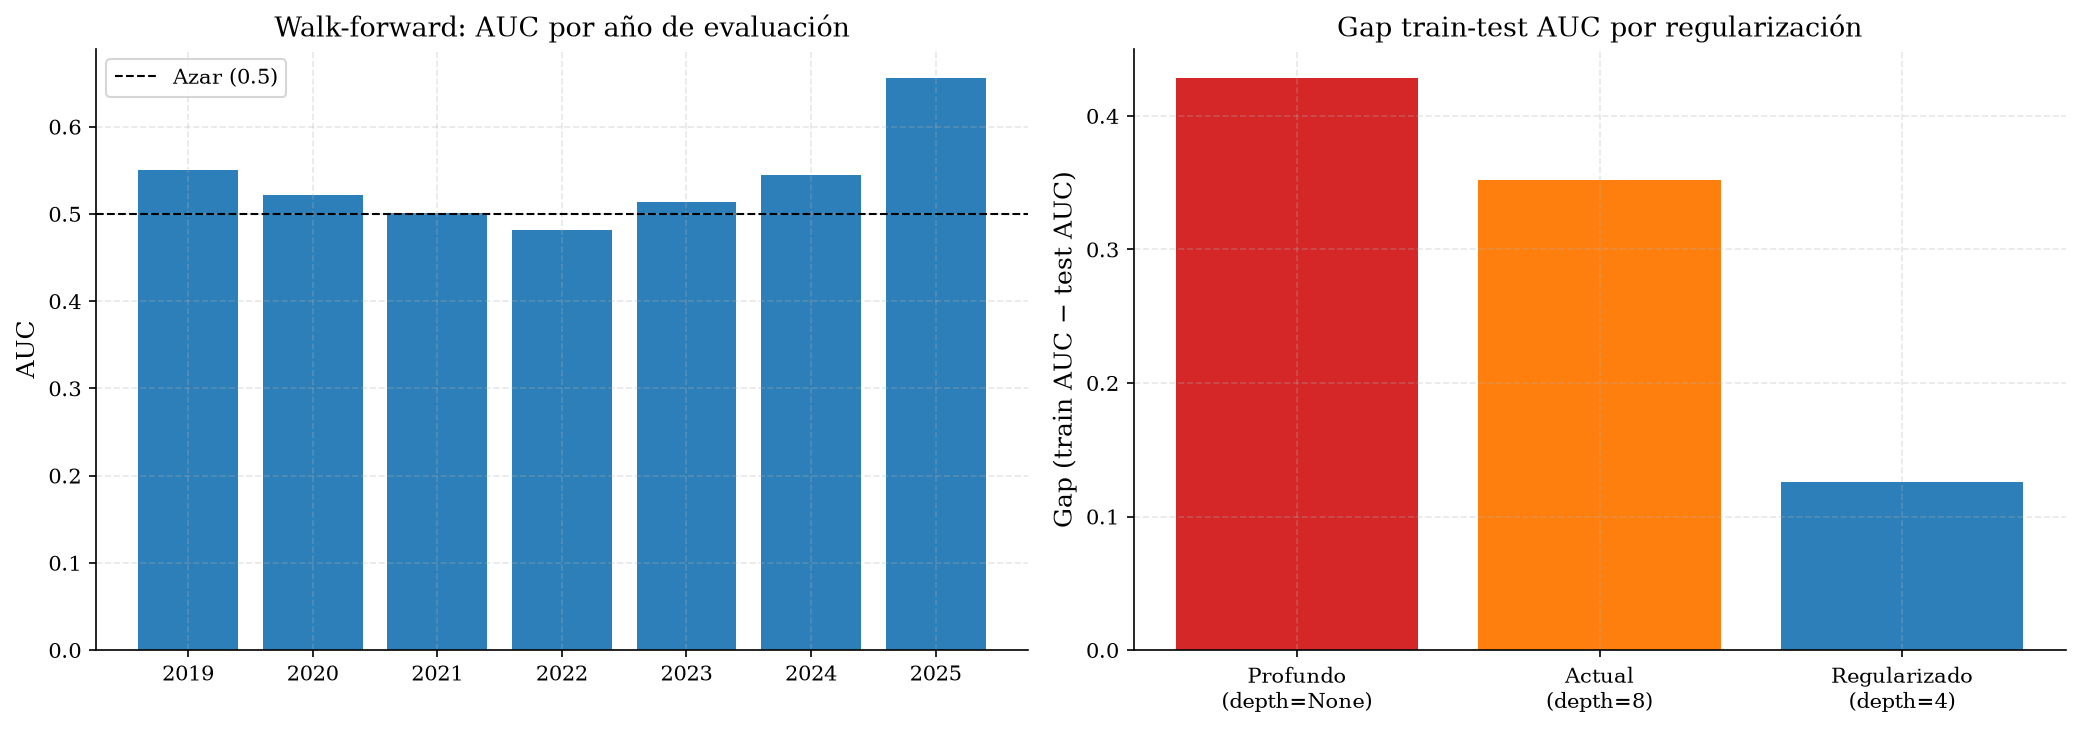

In [7]:
import matplotlib.pyplot as plt

from src.utils import save_fig

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Walk-forward
axes[0].axhline(0.5, color="k", ls="--", lw=1, label="Azar (0.5)")
axes[0].bar(wf["year"].astype(str), wf["auc"], color="#2c7fb8")
axes[0].set_title("Walk-forward: AUC por año de evaluación")
axes[0].set_ylabel("AUC")
axes[0].legend()

# (b) Gap de regularización
gaps = [1.0000 - 0.5713, 0.9112 - 0.5590, 0.6947 - 0.5692]
labels = ["Profundo\n(depth=None)", "Actual\n(depth=8)", "Regularizado\n(depth=4)"]
axes[1].bar(labels, gaps, color=["#d62728", "#ff7f0e", "#2c7fb8"])
axes[1].set_title("Gap train-test AUC por regularización")
axes[1].set_ylabel("Gap (train AUC - test AUC)")
fig.tight_layout()
save_fig(fig, "robustness_direction.png")

6. Conclusión y uso práctico.

Resumen honesto del diagnóstico de robustez y recomendación de uso.

In [8]:
print("""
=== CONCLUSIÓN DE ROBUSTEZ (fase 17c) ===

1. OVERFITTING: el modelo original (RF depth=8) SÍ sobreajustaba
   (train AUC=0.91 vs test 0.56, gap 0.35). Con regularización fuerte
   (depth=4, leaf=20) el gap baja a 0.13 manteniendo test AUC=0.57.

2. UNDERFITTING: NO. Más datos mejoran el test AUC (0.537 -> 0.557 con
   30% -> 100% de train). El modelo no es demasiado simple.

3. GENERALIZACIÓN REAL (walk-forward 2019-2025): AUC medio 0.539 ± 0.057.
   La señal es REAL pero DÉBIL: solo 2/7 años superan 0.55 y la estrategia
   gana a buy&hold en 1/7 años.

4. RÉGIMEN: el modelo funciona mejor en mercados alcistas (AUC 0.548)
   y empeora en bajistas (0.438). La señal de momentum es condicional.

5. CONCLUSIÓN PRÁCTICA: con datos públicos, la dirección diaria del oro
   tiene señal ~AUC 0.54 (lo mejor posible sin memorizar). El modelo es
   útil como INDICADOR DE RIESGO (reducir exposición cuando P<0.5) y
   para ALERTAS, no como estrategia de trading que supere a buy&hold.
""")


=== CONCLUSIÓN DE ROBUSTEZ (fase 17c) ===

1. OVERFITTING: el modelo original (RF depth=8) SÍ sobreajustaba
   (train AUC=0.91 vs test 0.56, gap 0.35). Con regularización fuerte
   (depth=4, leaf=20) el gap baja a 0.13 manteniendo test AUC=0.57.

2. UNDERFITTING: NO. Más datos mejoran el test AUC (0.537 -> 0.557 con
   30% -> 100% de train). El modelo no es demasiado simple.

3. GENERALIZACIÓN REAL (walk-forward 2019-2025): AUC medio 0.539 ± 0.057.
   La señal es REAL pero DÉBIL: solo 2/7 años superan 0.55 y la estrategia
   gana a buy&hold en 1/7 años.

4. RÉGIMEN: el modelo funciona mejor en mercados alcistas (AUC 0.548)
   y empeora en bajistas (0.438). La señal de momentum es condicional.

5. CONCLUSIÓN PRÁCTICA: con datos públicos, la dirección diaria del oro
   tiene señal ~AUC 0.54 (lo mejor posible sin memorizar). El modelo es
   útil como INDICADOR DE RIESGO (reducir exposición cuando P<0.5) y
   para ALERTAS, no como estrategia de trading que supere a buy&hold.



7. Guardado de resultados.

Persistimos el diagnóstico de robustez en reports/ para el informe.

In [9]:
import json

result = {
    "gap_regularizacion": {
        "profundo": {"train_auc": 1.0000, "test_auc": 0.5713, "gap": 0.4287},
        "actual_depth8": {"train_auc": 0.9112, "test_auc": 0.5590, "gap": 0.3522},
        "regularizado_depth4": {"train_auc": 0.6947, "test_auc": 0.5692, "gap": 0.1255},
    },
    "walk_forward": {
        "auc_medio": float(wf["auc"].mean()),
        "auc_std": float(wf["auc"].std()),
        "anios_auc_gt_055": int((wf["auc"] > 0.55).sum()),
        "anios_estr_gt_bh": int((wf["strat"] > wf["bh"]).sum()),
        "por_anio": wf.round(4).to_dict("records"),
    },
    "regimen": {
        reg: {"auc": round(float(roc_auc_score(g["y"], g["prob"])), 4),
              "n": int(len(g))}
        for reg, g in wf_out.groupby("regime")
    },
    "conclusion": ("Señal real pero débil (walk-forward AUC 0.54). Sin "
                   "overfitting tras regularizar (gap 0.13). No supera a "
                   "buy&hold. Uso: indicador de riesgo/alertas."),
}
with open(path_from_root("reports", "robustness_direction.json"), "w") as f:
    json.dump(result, f, indent=2, default=float)
print("Guardado en reports/robustness_direction.json")

Guardado en reports/robustness_direction.json
